# DBSCAN(WHOLESALE DATASET)

In [4]:
pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.


In [5]:
# step 1:import the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [6]:
# step 2:Load the dataset
df = pd.read_csv(r"C:\Users\HARSHITHA\Desktop\FSDS\DBSCAN\Wholesale\Wholesale customers data.csv")

In [7]:
# data exploration
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [8]:
df.info

<bound method DataFrame.info of      Channel  Region  Fresh   Milk  Grocery  Frozen  Detergents_Paper  \
0          2       3  12669   9656     7561     214              2674   
1          2       3   7057   9810     9568    1762              3293   
2          2       3   6353   8808     7684    2405              3516   
3          1       3  13265   1196     4221    6404               507   
4          2       3  22615   5410     7198    3915              1777   
..       ...     ...    ...    ...      ...     ...               ...   
435        1       3  29703  12051    16027   13135               182   
436        1       3  39228   1431      764    4510                93   
437        2       3  14531  15488    30243     437             14841   
438        1       3  10290   1981     2232    1038               168   
439        1       3   2787   1698     2510      65               477   

     Delicassen  
0          1338  
1          1776  
2          7844  
3          1788  
4

In [9]:
df.shape

(440, 8)

In [10]:
# check teh missing values
print(df.isnull().sum())

Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64


In [11]:
# select features for the dbscan
features = [
    'Fresh',
    'Milk',
    'Grocery',
    'Frozen',
    'Detergents_Paper',
    'Delicassen'
]

X = df[features]

print(X.head())

   Fresh  Milk  Grocery  Frozen  Detergents_Paper  Delicassen
0  12669  9656     7561     214              2674        1338
1   7057  9810     9568    1762              3293        1776
2   6353  8808     7684    2405              3516        7844
3  13265  1196     4221    6404               507        1788
4  22615  5410     7198    3915              1777        5185


In [13]:
from sklearn.preprocessing import StandardScaler

In [14]:
# Feature scaling
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[ 0.05293319  0.52356777 -0.04111489 -0.58936716 -0.04356873 -0.06633906]
 [-0.39130197  0.54445767  0.17031835 -0.27013618  0.08640684  0.08915105]
 [-0.44702926  0.40853771 -0.0281571  -0.13753572  0.13323164  2.24329255]
 [ 0.10011141 -0.62401993 -0.3929769   0.6871443  -0.49858822  0.09341105]
 [ 0.84023948 -0.05239645 -0.07935618  0.17385884 -0.23191782  1.29934689]]


In [16]:
from sklearn.cluster import DBSCAN

In [17]:
# Apply dbscan
dbscan = DBSCAN(eps=1.5, min_samples=5)

labels = dbscan.fit_predict(X_scaled)

print(labels)

[ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 -1
  0  0  0  0 -1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 -1  0 -1
  0  0  0  0  0  0  0  0  0  0  0  0  0 -1  0  0  0 -1  0  0  0  0  0 -1
  0  0  0  0  0  0  0  0  0  0  0  0  0 -1 -1 -1  0  0  0  0 -1 -1  0  0
  0  0  0  0  0  0  0 -1  0  0  0  0  0 -1  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0 -1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0 -1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0 -1  0  0  0  0  0  0  0  0  0 -1  0 -1  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 -1  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0 -1  0  0  0  0  0  0  0  0  0  0  0  0
  0 -1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 -1  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0 -1  0  0  0

In [18]:
# add cluster labels to the dataset
df['Cluster'] = labels

print(df.head())

   Channel  Region  Fresh  Milk  Grocery  Frozen  Detergents_Paper  \
0        2       3  12669  9656     7561     214              2674   
1        2       3   7057  9810     9568    1762              3293   
2        2       3   6353  8808     7684    2405              3516   
3        1       3  13265  1196     4221    6404               507   
4        2       3  22615  5410     7198    3915              1777   

   Delicassen  Cluster  
0        1338        0  
1        1776        0  
2        7844        0  
3        1788        0  
4        5185        0  


In [19]:
# count the number of clusters
print("Cluster counts:")
print(df['Cluster'].value_counts())

Cluster counts:
Cluster
 0    413
-1     27
Name: count, dtype: int64


In [20]:
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

print("Number of clusters:", n_clusters)

Number of clusters: 1


In [21]:
# count the noise points
noise_points = list(labels).count(-1)

print("Number of noise points:", noise_points)

Number of noise points: 27


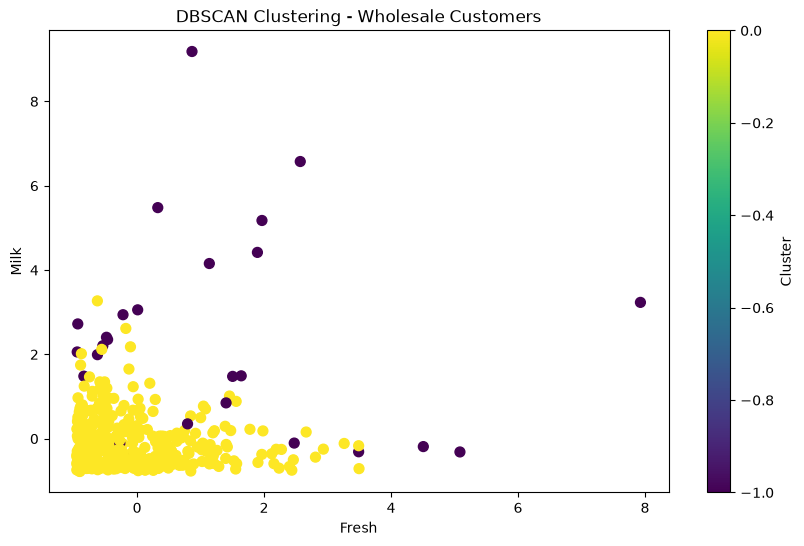

In [22]:
# visualize the clusters
plt.figure(figsize=(10, 6))

plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=labels,
    cmap='viridis',
    s=50
)

plt.xlabel("Fresh")
plt.ylabel("Milk")
plt.title("DBSCAN Clustering - Wholesale Customers")

plt.colorbar(label="Cluster")
plt.show()

In [23]:
# calculate the silhoute score
unique_labels = set(labels)

if len(unique_labels - {-1}) >= 2:
    score = silhouette_score(
        X_scaled,
        labels,
        metric='euclidean'
    )
    print("Silhouette Score:", score)
else:
    print("Silhouette Score cannot be calculated because there are fewer than 2 clusters.")

Silhouette Score cannot be calculated because there are fewer than 2 clusters.


In [24]:
# try different eps values
eps_values = [0.5, 0.7, 0.9, 1.1, 1.3, 1.5, 1.7, 2.0]

for eps in eps_values:

    model = DBSCAN(eps=eps, min_samples=5)
    labels_temp = model.fit_predict(X_scaled)

    clusters = len(set(labels_temp)) - (1 if -1 in labels_temp else 0)
    noise = list(labels_temp).count(-1)

    print(
        "eps =", eps,
        "| clusters =", clusters,
        "| noise =", noise
    )

eps = 0.5 | clusters = 2 | noise = 174
eps = 0.7 | clusters = 1 | noise = 97
eps = 0.9 | clusters = 1 | noise = 54
eps = 1.1 | clusters = 1 | noise = 45
eps = 1.3 | clusters = 1 | noise = 33
eps = 1.5 | clusters = 1 | noise = 27
eps = 1.7 | clusters = 1 | noise = 20
eps = 2.0 | clusters = 1 | noise = 13
